# Phase 1 - Part B: Supervised Learning
## Customer Churn Prediction
### Models: Logistic Regression | Decision Tree | Random Forest 

## Introduction

This file presents the supervised learning phase of the project, where multiple classification models are developed to predict customer churn. The goal is to identify customers who are likely to leave the bank.

Three models are implemented and evaluated: Logistic Regression, Decision Tree, and Random Forest. Each model is trained, tuned, and assessed using appropriate evaluation metrics to ensure reliable performance, particularly in the presence of class imbalance.

## 1. Import Libraries

We import all necessary libraries for:
- **Data handling**: pandas, numpy
- **Visualization**: matplotlib, seaborn
- **Machine learning models**: scikit-learn (Logistic Regression, Decision Tree, Random Forest)
- **Evaluation**: metrics such as accuracy, confusion matrix, ROC-AUC

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Preprocessed Dataset

We load the preprocessed dataset prepared in Phase 1A. This dataset has already been cleaned, encoded, and feature engineered. Feature scaling is applied later in this phase after splitting the data to prevent data leakage, while class imbalance handling (SMOTE) is integrated within model training pipelines.

In [ ]:
# Load the preprocessed dataset
df = pd.read_csv("Dataset/Preprocessed_Churn_Modelling_Data.csv")

# Display dataset dimensions to confirm successful loading
print("Dataset shape:", df.shape)

# Preview the first rows
df.head()

Dataset shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus,LogCustomerValue
0,619,42,2,0.00,1,1,1,101348.88,1,0,0.00,0,0,0,0,0,1,0,0,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,0,1,83807.86,0,0,1,0,0,1,0,0,11.336294
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0.00,1,0,0,0,0,1,0,0,13.079421
3,699,39,1,0.00,2,0,0,93826.63,0,0,0.00,0,0,0,0,1,0,0,0,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,0,1,125510.82,0,0,1,0,0,1,0,0,11.740155


## 3. Separate Features and Target Variable

We split the dataset into:
- **X**: all input features (19 features) — the variables used by the model for prediction
- **y**: the target variable `Exited` — what the model predicts
  - 0 = Customer stayed (7963 customers)
  - 1 = Customer churned (2037 customers)

The dataset is imbalanced, with about 80% non-churned customers and 20% churned customers. This imbalance must be considered during model training and evaluation.

In [ ]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

# Show shapes of features and target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Show class distribution of the target variable
print("Churn distribution:\n", y.value_counts())

Features shape: (10000, 19)
Target shape: (10000,)
Churn distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


## 4. Split Data into Training and Testing Sets

We split the data into:
- **80% training** — used to train the models
- **20% testing** — used to evaluate performance on unseen data

`stratify=y` ensures the same churn ratio exists in both splits, while
`random_state=42` ensures reproducibility.

In [ ]:
# Split the dataset into training and testing sets
# stratify=y preserves the same churn ratio in both sets
# random_state=42 ensures the same split each time the code is run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every run
    stratify=y          # keeps churn ratio balanced
)


# Display shapes of the resulting datasets
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Display class distribution in both splits
print("Train churn distribution:\n", y_train.value_counts())
print("Test churn distribution:\n", y_test.value_counts())

Training set size: (8000, 19)
Testing set size: (2000, 19)
Train churn distribution:
 Exited
0    6370
1    1630
Name: count, dtype: int64
Test churn distribution:
 Exited
0    1593
1     407
Name: count, dtype: int64


## 5. Feature Scaling

We apply `StandardScaler` after splitting the data to prevent data leakage. The scaler is fitted only on the training data and then applied to the test data using the same transformation.

Only continuous numerical features are scaled, while binary and one-hot encoded features are excluded to preserve their meaning.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select only continuous numerical features to scale
# Binary and one-hot encoded columns are excluded
feature_scale_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'ActiveBalance', 'LogCustomerValue'
]

# Keep only columns that actually exist in the dataset
feature_scale_cols = [col for col in feature_scale_cols if col in X_train.columns]

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data only and transform the training set
X_train[feature_scale_cols] = scaler.fit_transform(X_train[feature_scale_cols])

# Apply the same transformation to the test set
X_test[feature_scale_cols] = scaler.transform(X_test[feature_scale_cols])


# Confirm which columns were scaled
print("Scaling applied successfully!")
print("Scaled columns:", feature_scale_cols)

Scaling applied successfully!
Scaled columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'ActiveBalance', 'LogCustomerValue']


## 6. Handle Class Imbalance (SMOTE)

The dataset is imbalanced, with significantly more non-churned customers than churned customers. This imbalance can cause the model to favor the majority class and reduce its ability to correctly detect churned customers.

A straightforward approach would be to apply SMOTE directly to the training data after the train-test split. While this avoids leaking information into the test set, it still introduces a problem when using cross-validation.

If SMOTE is applied once to the entire training set before cross-validation:
- Synthetic samples are created using information from the full training set  
- During cross-validation these synthetic samples may appear in both training and validation folds  
- This leads to data leakage within cross-validation, producing overly optimistic and unreliable results  

To avoid this issue, SMOTE is not applied globally at this step.

Instead, SMOTE is integrated within each model’s training pipeline, where it is applied only to the training portion of each fold during cross-validation. The validation and test data remain completely untouched.

This approach ensures:
- No data leakage (neither from test set nor between folds)  
- Fair and realistic model evaluation  
- Better generalization to unseen data  

The test set remains imbalanced to reflect real-world conditions.

In [ ]:
from imblearn.over_sampling import SMOTE

# Show class distribution before applying SMOTE
# This is only for reference; SMOTE will be applied later inside model pipelines
before_dist = pd.Series(y_train).value_counts()

print("Before SMOTE - Class distribution:")
print(before_dist)

Before SMOTE - Class distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64


## 7. Evaluation Metrics

We evaluate the models using multiple performance metrics to obtain a comprehensive understanding of their effectiveness, especially because the dataset is imbalanced.

Accuracy alone is not sufficient, since a model can achieve high accuracy by favoring the majority class (non-churned customers). Therefore, additional metrics are needed to assess performance on churn detection more fairly.

- **Accuracy:** Measures the overall percentage of correctly classified customers  
- **Precision:** Measures how many customers predicted as churned actually churned  
- **Recall (Sensitivity):** Measures how many actual churned customers were correctly identified  
- **F1-Score:** Provides a balance between precision and recall  
- **ROC-AUC Score:** Measures how well the model separates churned and non-churned customers across all classification thresholds  

Since the business objective is to detect customers at risk of leaving, **Recall** and **ROC-AUC** are especially important in this project.

## 8. Model 1: Logistic Regression

Logistic Regression is a supervised learning algorithm used for binary classification problems. It predicts the probability that a given input belongs to a specific class by applying a logistic (sigmoid) function to a linear combination of input features.

Instead of predicting a continuous value, the model outputs a probability between 0 and 1, which is then converted into a class label (churn or no churn) using a threshold, typically 0.5.

In this project, Logistic Regression is used to estimate the probability that a customer will churn based on their features.

### Overview
In this section we train a Logistic Regression model to predict customer churn.
We will:
1. Tune hyperparameters using GridSearchCV
2. Evaluate performance using multiple metrics
3. Analyze the confusion matrix and ROC curve
4. Validate consistency using K-Fold Cross Validation
### 8.1 Model Selection Rationale
Logistic Regression is selected based on the following dataset-specific reasons:

- **Binary target:** The dataset has a binary outcome (Exited = 0 or 1), which Logistic Regression is well-suited for.

- **Mostly numerical and scaled features:** The dataset contains several continuous numerical features such as CreditScore, Age, Balance, EstimatedSalary, ActiveBalance, and LogCustomerValue. These features are standardized during preprocessing, which improves the convergence and performance of Logistic Regression.

- **Feature interpretability:** The model coefficients provide clear insights into how each feature contributes to churn prediction, which is valuable for understanding customer behavior and supporting business decisions.

- **Baseline model:** Logistic Regression serves as a strong and interpretable baseline for comparison with more complex models such as Decision Tree and Random Forest.

### Limitations

- **Linear decision boundary:** Logistic Regression assumes a linear relationship between features and the log-odds of the target, which may limit its ability to capture complex non-linear patterns, so the model may underperform when important interactions or non-linear dependencies exist between features



### 8.2 Implementation & Training Code

In this step, we train a baseline Logistic Regression model to establish an initial performance benchmark before applying hyperparameter tuning.

The baseline model is intentionally trained on the original imbalanced dataset to reflect the true data distribution and highlight the limitations of standard classification under class imbalance.

This allows us to establish a realistic performance benchmark and demonstrate the impact of imbalance, particularly on the model’s ability to detect churned customers.

To address this issue properly, SMOTE is not applied at the baseline stage. Instead, it is integrated within the model training pipeline during hyperparameter tuning using cross-validation. This ensures that oversampling is applied only to the training folds, preventing data leakage and enabling a fair and reliable evaluation.

In [8]:
# Initialize Logistic Regression with default parameters
lr_model = LogisticRegression(max_iter=2000, random_state=42)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, lr_pred), 3))

Logistic Regression trained successfully!
Initial Accuracy: 0.827


The high baseline accuracy is influenced by class imbalance, as predicting the majority class (non-churners) yields high accuracy but fails to adequately capture the minority class (churned customers).

### 8.3 Hyperparameter Tuning Process & Results
In machine learning, hyperparameters are configuration settings that are defined before training the model and are not learned from the data. They control how the model learns and can significantly impact performance.

For Logistic Regression, important hyperparameters include:
- **C**: Controls the strength of regularization (smaller values = stronger regularization)
- **penalty**: Specifies the type of regularization (L1 or L2)
- **solver**: Determines the optimization algorithm used to train the model

To find the best combination of these hyperparameters, we use **GridSearchCV**, which systematically evaluates multiple parameter combinations using cross-validation.

To properly handle class imbalance during tuning, SMOTE is integrated within a pipeline. This ensures that oversampling is applied only to the training folds during cross-validation, preventing data leakage and ensuring a fair evaluation.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline: SMOTE + Logistic Regression
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

# Improved hyperparameter grid
param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],  # lbfgs supports only l2
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

# Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

# Train model
grid_search.fit(X_train, y_train)

# Best results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", round(grid_search.best_score_, 3))

# Best model
lr_model = grid_search.best_estimator_

# Predictions
lr_pred = lr_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, lr_pred), 3))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best Cross-Validation F1 Score: 0.504
Accuracy with best params: 0.729


### Hyperparameter Tuning Results

GridSearchCV evaluated multiple parameter combinations using 5-fold cross-validation, optimizing for **F1-score** to better handle class imbalance.

**Best Configuration:**  
C = 0.001, penalty = L2, solver = liblinear

| Parameter | Value  | Justification |
|----------|--------|--------------|
| C        | 0.001  | Strong regularization — reduces model complexity and prevents over-reliance on specific features in this tabular dataset |
| penalty  | L2     | Ridge regularization — stabilizes coefficients without removing features |
| solver   | liblinear | Efficient for binary classification and supports L2 regularization |

Although this configuration results in lower overall accuracy compared to the baseline model (0.729 vs 0.827), this reflects a trade-off between overall accuracy and improved sensitivity to the minority class.

During tuning, we optimized for F1-score instead of accuracy because it better balances precision and recall, especially for the minority class (churned customers). As a result, the model is optimized to better balance precision and recall rather than simply favoring the majority class.

The selected parameters reflect this behavior: a low C value (0.001) enforces strong regularization, improving generalization, while the liblinear solver provides a stable and efficient solution for binary classification.

Overall, the tuned model provides more meaningful performance for churn prediction by prioritizing minority class detection over raw accuracy.

### 8.4 Evaluation Metrics & Visualizations
We evaluate the Logistic Regression model using the previously defined metrics to assess its classification performance.

In [10]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
lr_proba = lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, lr_proba))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.74      0.81      1593
 Churned (1)       0.40      0.69      0.51       407

    accuracy                           0.73      2000
   macro avg       0.65      0.72      0.66      2000
weighted avg       0.80      0.73      0.75      2000

ROC-AUC Score: 0.7754996907539279


### Evaluation Results

The model achieved an overall accuracy of **73%**. While this indicates reasonable overall performance, accuracy alone is not sufficient due to class imbalance in the dataset.

#### Performance on Stayed class (0):
- **Precision: 0.90** — most customers predicted as stayed are actually non-churners
- **Recall: 0.74** — the model correctly identifies 74% of actual non-churners
- **F1-Score: 0.81** — strong performance on the majority class

#### Performance on Churned class (1):
- **Precision: 0.40** — when churn is predicted, it is correct 40% of the time (relatively high false positive rate)
- **Recall: 0.69** — the model identifies 69% of actual churners
- **F1-Score: 0.51** — moderate performance on the minority class

#### ROC-AUC: 0.775
The model demonstrates moderate ability to distinguish between churned and non-churned customers, performing clearly above the random baseline (0.5).

#### Key Finding:
The model performs well on the majority class (non-churners), but its ability to accurately predict churned customers is more limited. This imbalance in performance reflects the underlying class imbalance in the dataset and the linear nature of Logistic Regression, which may not fully capture complex patterns.

### Metrics Interpretation

- **Stayed class:** A precision of 0.90 indicates that most customers predicted as stayed are indeed non-churners. The recall of 0.74 shows that a large portion of actual non-churners are correctly identified, contributing to the overall accuracy.

- **Churned class:** A precision of 0.40 indicates a relatively high false positive rate — many customers predicted as churners are actually loyal. However, the recall of 0.69 shows the model is reasonably effective at identifying churners, which is important for retention strategies.

- **ROC-AUC (0.775):** The model has moderate discriminative ability, meaning it can distinguish between churned and non-churned customers better than random guessing.

- **Business Perspective:** In churn prediction, recall is often prioritized over precision, since missing a churner (false negative) is typically more costly than incorrectly flagging a loyal customer (false positive). Therefore, the model’s relatively higher recall for churners is valuable despite lower precision.

### Logistic Regression - Confusion Matrix 

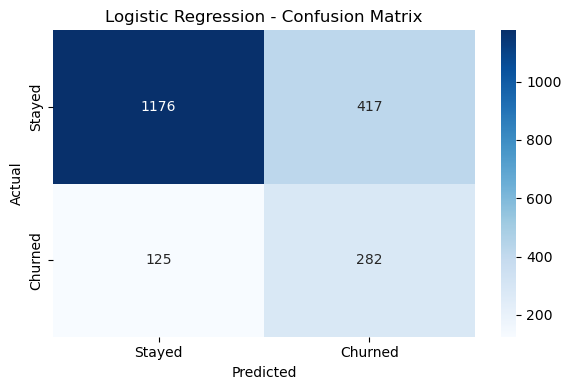

In [11]:
# Confusion Matrix heatmap - Logistic Regression
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides a detailed breakdown of the model’s classification performance:

- **True Negatives (1176):** The model correctly identified a large number of non-churning customers.
- **False Positives (417):** A significant number of non-churners were incorrectly predicted as churners, which may lead to unnecessary retention efforts.
- **False Negatives (125):** Some churners were missed by the model — predicted to stay but actually left, representing missed retention opportunities.
- **True Positives (282):** The model correctly identified a substantial portion of churned customers, enabling targeted retention actions.

### What this graph represents

The confusion matrix compares actual vs predicted classifications, allowing us to evaluate model performance for each class and identify where errors occur.

### Insight

The model performs well in identifying customers who will stay, as shown by the high number of true negatives. It also captures a reasonable portion of churners, but still misses some, as indicated by the false negatives.

Additionally, the relatively high number of false positives suggests that the model tends to over-predict churn, flagging some loyal customers as at risk.

### What we learned

The model demonstrates a trade-off between detecting churners and maintaining overall accuracy.

- It prioritizes **recall (detecting churners)**  
- At the cost of **precision (more false alarms)**  

This behavior is common in imbalanced classification problems.

From a business perspective, this trade-off is often acceptable, as missing a churner (false negative) is typically more costly than incorrectly targeting a loyal customer (false positive).

### Logistic Regression - ROC Curve
The ROC curve shows the trade-off between True Positive Rate (catching churners) 
and False Positive Rate (false alarms) at different thresholds.
AUC closer to 1.0 means better model performance.

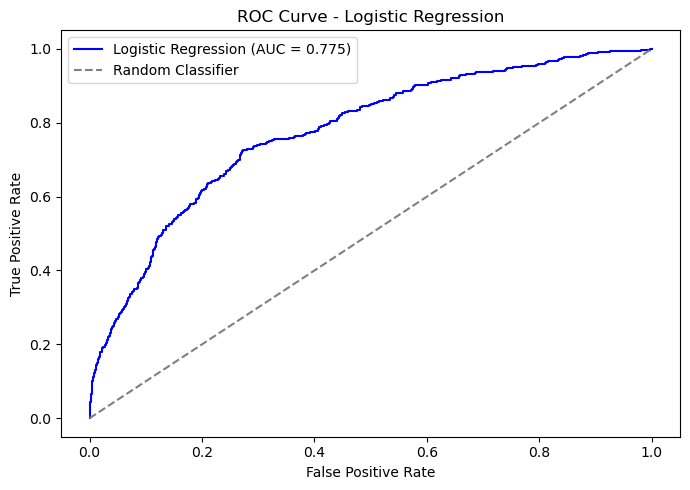

ROC-AUC Score: 0.7754996907539279


In [12]:
# Calculate ROC curve points
lr_proba = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
auc_score = roc_auc_score(y_test, lr_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", auc_score)

### ROC Curve Interpretation

**ROC-AUC Score: 0.775**

The ROC curve lies above the diagonal baseline, indicating that the model performs better than random classification.

An AUC score of 0.775 suggests that the model has **moderate discriminative ability**, meaning it can reasonably distinguish between churned and non-churned customers across different classification thresholds.

### What this graph represents

The ROC curve illustrates the trade-off between True Positive Rate (Recall) and False Positive Rate across different classification thresholds. It provides a threshold-independent measure of how well the model distinguishes between classes.

### What we learned

The ROC-AUC score indicates that the model is reasonably effective at ranking customers by their likelihood of churn, even if it does not perfectly classify all cases.

While the model performs well overall, its moderate AUC score suggests there is still room for improvement, particularly in better separating churned and non-churned customers.

### Logistic Regression - K-Fold Cross Validation
K-Fold Cross Validation is used to evaluate the stability and generalization of the model. The data is split into 5 folds, where the model is trained on 4 folds and validated on the remaining fold. This process is repeated across all folds to ensure the model’s performance is consistent and not dependent on a single train-test split.

SMOTE is applied within the pipeline to ensure that oversampling occurs only on the training folds during each iteration, preventing data leakage.


In [13]:
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline


lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000, random_state=42, 
                                  C=0.001, penalty='l2', solver='liblinear'))
])

cv_results = cross_validate(lr_pipeline, X_train, y_train, cv=5, 
                             scoring=['f1', 'roc_auc', 'accuracy'])

print("Logistic Regression - 5-Fold Cross Validation Results:")
print("="*50)
print("F1 Scores:", cv_results['test_f1'])
print("Mean F1:", cv_results['test_f1'].mean().round(3))
print("Std F1:", cv_results['test_f1'].std().round(3))
print("\nROC-AUC Scores:", cv_results['test_roc_auc'])
print("Mean ROC-AUC:", cv_results['test_roc_auc'].mean().round(3))
print("Std ROC-AUC:", cv_results['test_roc_auc'].std().round(3))
print("\nAccuracy Scores:", cv_results['test_accuracy'])
print("Mean Accuracy:", cv_results['test_accuracy'].mean().round(3))
print("Std Accuracy:", cv_results['test_accuracy'].std().round(3))

Logistic Regression - 5-Fold Cross Validation Results:
F1 Scores: [0.496614   0.51843318 0.50406504 0.51162791 0.48747153]
Mean F1: 0.504
Std F1: 0.011

ROC-AUC Scores: [0.76611994 0.77528147 0.769799   0.77496364 0.75580029]
Mean ROC-AUC: 0.768
Std ROC-AUC: 0.007

Accuracy Scores: [0.72125  0.73875  0.733125 0.7375   0.71875 ]
Mean Accuracy: 0.73
Std Accuracy: 0.008


### K-Fold Cross Validation Results

| Metric   | Mean  | Std   |
|----------|------:|------:|
| F1 Score | 0.504 | 0.011 |
| ROC-AUC  | 0.768 | 0.007 |
| Accuracy | 0.730 | 0.008 |

### Interpretation

- **F1 Score (0.504):** Indicates moderate performance in detecting churners, with consistent results across all folds.
- **ROC-AUC (0.768):** Shows stable discriminative ability across different splits.
- **Accuracy (0.730):** Remains consistent across folds, reflecting stable overall classification performance.
- **Low standard deviation:** Indicates that the model generalizes well and its performance is not highly sensitive to data splitting.

### 8.5 Results Summary

| Metric | Value |
|--------|-------|
| Accuracy | 73% |
| F1 - Stayed | 0.81 |
| F1 - Churned | 0.51 |
| ROC-AUC | 0.775 |


**What these metrics mean for our dataset:**
- **Accuracy (73%):** Overall correct classification rate across both classes, but may be misleading due to class imbalance
- **Precision (Churned = 0.40):** When churn is predicted, it is correct 40% of the time (indicates false alarms)
- **Recall (Churned = 0.69):** The model detects 69% of actual churners (important for retention)
- **F1-Score (Churned = 0.51):** Balanced measure between precision and recall for the minority class
- **ROC-AUC (0.775):** Moderate ability to distinguish between churned and non-churned customers


**Misclassification Analysis:**

| | Predicted Stayed | Predicted Churned |
|---|---|---|
| **Actually Stayed** | 1176 | 417 |
| **Actually Churned** | 125 | 282 |

- **125 False Negatives (missed churners):** Most costly — customers leave without retention intervention  
- **417 False Positives (false alarms):** Leads to unnecessary retention efforts toward loyal customers  


**Business Impact:**
The model detects **282 out of 407 churners (69% recall)**, allowing the bank to proactively target the majority of at-risk customers. However, the relatively high number of false positives (417) means retention resources may be spent on customers who were not planning to leave.


**Conclusion:**  
Logistic Regression provides a solid baseline for binary churn classification. While it performs well on the majority class, its linear decision boundary limits its ability to capture complex non-linear relationships in customer behavior. Future models such as Decision Trees and Random Forests are expected to improve precision while maintaining or enhancing recall.

### Save Evaluation Result

In [14]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned'])
with open('Supervised_Learning/evaluation_results/lr_classification_report.txt', 'w') as f:
    f.write(report)

print("Saved!")

Saved!


### Save Visualization

In [15]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_confusion_matrix.png')
plt.close()

# Save ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_proba)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color='blue', label=f'LR (AUC = {roc_auc_score(y_test, lr_proba):.3f})')
ax.plot([0,1], [0,1], 'g--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_roc_curve.png')
plt.close()

print("Plots saved successfully!")

Plots saved successfully!


## 9. Model 2: Decision Tree

### Overview
In this section we train a Decision Tree model to predict customer churn.
We will:
1. Tune hyperparameters using GridSearchCV
2. Evaluate performance using multiple metrics
3. Analyze the confusion matrix and ROC curve
4. Validate consistency using K-Fold Cross Validation

### 9.1 Model Selection Rationale
Decision Tree is selected based on the following dataset-specific reasons:
- **Non-linear relationships**: Customer churn is influenced by complex interactions between features such as Age, Balance, NumOfProducts, and IsActiveMember. Decision Trees can effectively capture these patterns.
- **Interpretability**: The model provides clear decision rules, making it easier to understand how features influence churn predictions.

### Limitations
- Can easily **overfit** the training data if not properly tuned
- Sensitive to small changes in the dataset, which may lead to different tree structures

### 9.2 Implementation & Training Code

The model is implemented using scikit-learn's DecisionTreeClassifier.
An initial model is trained below, followed by hyperparameter tuning in Section 9.3 to improve performance.

In [16]:
# Initialize Decision Tree with default parameters
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on training data
dt_model.fit(X_train, y_train)

# Predict on test data
dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, dt_pred), 3))

Decision Tree trained successfully!
Initial Accuracy: 0.79


### 9.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for the model in order to improve performance and control model complexity.

In [17]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'class_weight': [None, 'balanced']
}

# Grid search with 5-fold cross validation
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best ROC-AUC Score:", dt_grid.best_score_.round(3))

# Retrain with best parameters
dt_model = dt_grid.best_estimator_
dt_pred = dt_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, dt_pred), 3))

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 100}
Best ROC-AUC Score: 0.844
Accuracy with best params: 0.86


### Hyperparameter Tuning Results

GridSearchCV evaluated multiple parameter combinations using 5-fold cross-validation, optimizing for **ROC-AUC score** to better handle class imbalance.

**Best Configuration:** `max_depth=7`, `min_samples_split=100`, `min_samples_leaf=10`, `class_weight=None`

| Parameter | Value | Justification |
|----------|------:|---------------|
| max_depth | 7 | Controls tree depth to prevent overfitting while still capturing important patterns in customer behavior |
| min_samples_split | 100 | Prevents splits on small sample sizes, improving model generalization |
| min_samples_leaf | 10 | Ensures each leaf has enough samples, improving stability and reducing variance |
| class_weight | None | Re-weighting did not improve performance, indicating the model handles class distribution adequately |

### Observation

- The tuned model achieved an **accuracy of 0.86**, improving from the initial accuracy of **0.789**
- The ROC-AUC score reached **0.844**, indicating good ability to distinguish between churned and non-churned customers
- Overall, hyperparameter tuning successfully improved model performance

### 9.4 Evaluation Metrics & Visualizations

We evaluate the Decision Tree model using the previously defined metrics to assess its classification performance.

In [18]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
dt_proba = dt_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, dt_proba))



Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.95      0.92      1593
 Churned (1)       0.72      0.51      0.59       407

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC Score: 0.8452466333822266


### Evaluation Results

The model achieved an overall accuracy of **86%**.

Performance on Stayed class (0):

- **Precision: 0.88** — 88% of customers predicted to stay actually stayed  
- **Recall: 0.95** — 95% of actual non-churners were correctly identified  
- **F1-Score: 0.92** — strong performance on the majority class  

Performance on Churned class (1):

- **Precision: 0.72** — when churn is predicted, it is correct 72% of the time  
- **Recall: 0.51** — only 51% of actual churners were detected  
- **F1-Score: 0.59** — moderate performance on the minority class  

**ROC-AUC: 0.845**

**Key Finding:** The model shows strong performance in identifying non-churning customers, but struggles to detect churned customers due to class imbalance. This indicates that further improvement is needed, particularly in increasing recall for the churned class.

### Metrics Interpretation

- **Stayed class (0):** High precision (0.88) and very high recall (0.95) — the model correctly identifies most non-churning customers with strong reliability  

- **Churned class (1):** Moderate precision (0.72) but low recall (0.51) — the model detects only about half of actual churners, meaning many churn cases are still missed  

- **ROC-AUC (0.845):** Indicates good overall ability to distinguish between churned and non-churned customers  

- **Class imbalance effect:** Performance is noticeably better for the majority class (stayed) compared to the minority class (churned), which is expected in imbalanced datasets  

- **Recall remains critical:** Missing churners is costly from a business perspective — improving recall for the churned class should be a priority in future improvements  

### Decision Tree - Confusion Matrix

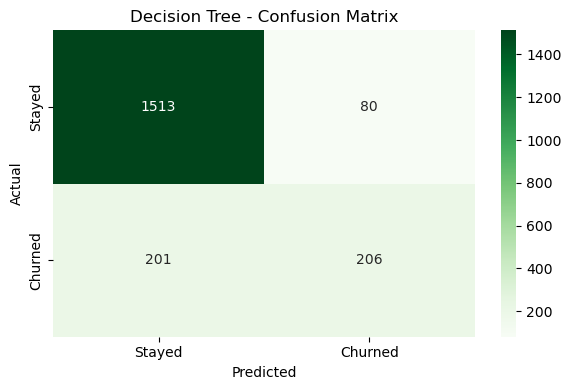

In [19]:
# Confusion Matrix heatmap - Decision Tree
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides a detailed breakdown of the model’s classification performance:

- **True Negatives (1513)**: The model correctly identified a large number of non-churning customers  
- **False Positives (80)**: A small number of non-churners were incorrectly predicted as churners  
- **False Negatives (201)**: A significant number of churners were missed by the model  
- **True Positives (206)**: The model successfully identified some churned customers  

### What this graph represents:

The confusion matrix shows the comparison between actual and predicted classifications, allowing us to evaluate how well the model performs in identifying each class and where errors occur.

### Insight:

The model performs very well in identifying customers who will stay, as shown by the high number of true negatives. However, it struggles to detect all churners, as indicated by the relatively high number of false negatives.

This suggests that while the model is reliable for predicting non-churn, it still needs improvement in detecting at-risk customers.

### What we learned:

The model is highly effective at identifying non-churning customers but less effective at detecting churners.  

This highlights the impact of class imbalance and indicates that further improvements are needed to increase recall for the churned class, especially for business-critical decision making.

### Decision Tree - ROC Curve

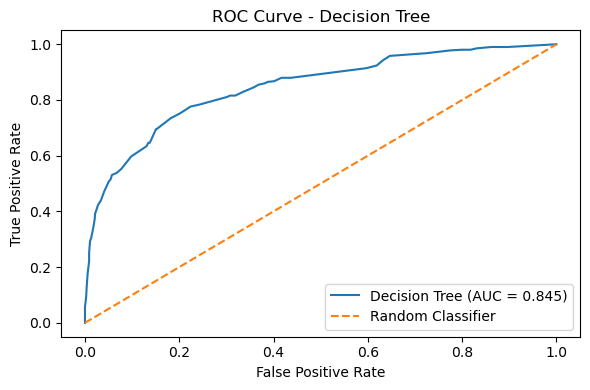

ROC-AUC Score: 0.8452466333822266


In [20]:
# Predict probabilities for the positive class (Churn = 1)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Compute ROC curve values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)

# Compute ROC-AUC score
dt_auc = roc_auc_score(y_test, dt_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", dt_auc)

### ROC Curve Interpretation

ROC-AUC Score: 0.845

The ROC curve lies above the diagonal baseline, indicating the model performs better than random guessing.

Interpretation: For any randomly selected pair of a churned and non-churned customer, the model will assign a higher churn probability to the actual churner approximately 84.5% of the time. This falls within the "Good" range (0.8 – 0.9), indicating solid discriminative ability.

### What this graph represents:

The ROC curve shows the trade-off between the True Positive Rate (Recall) and False Positive Rate across different classification thresholds. It helps evaluate how well the model can distinguish between churned and non-churned customers regardless of a specific threshold.

### What we learned:

The improved ROC-AUC compared to Logistic Regression reflects the Decision Tree’s ability to capture non-linear relationships between features such as Age, Balance, and IsActiveMember, which are important in modeling customer churn behavior.

This indicates that the model is effective at ranking customers by their likelihood of churn, even if it does not perfectly classify all cases.

### Decision Tree - K-Fold Cross Validation 

In [21]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Pipeline: SMOTE applied inside each fold
dt_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

# 5-Fold Cross Validation
dt_cv_f1 = cross_val_score(dt_pipeline, X, y, cv=5, scoring='f1')
dt_cv_roc = cross_val_score(dt_pipeline, X, y, cv=5, scoring='roc_auc')
dt_cv_acc = cross_val_score(dt_pipeline, X, y, cv=5, scoring='accuracy')

print("Decision Tree - 5-Fold Cross Validation Results:")
print("="*50)

print("F1 Scores:", dt_cv_f1)
print("Mean F1:", dt_cv_f1.mean().round(3))
print("Std F1:", dt_cv_f1.std().round(3))

print("\nROC-AUC Scores:", dt_cv_roc)
print("Mean ROC-AUC:", dt_cv_roc.mean().round(3))
print("Std ROC-AUC:", dt_cv_roc.std().round(3))

print("\nAccuracy Scores:", dt_cv_acc)
print("Mean Accuracy:", dt_cv_acc.mean().round(3))
print("Std Accuracy:", dt_cv_acc.std().round(3))

Decision Tree - 5-Fold Cross Validation Results:
F1 Scores: [0.48390677 0.5170068  0.48045977 0.48190045 0.46332945]
Mean F1: 0.485
Std F1: 0.017

ROC-AUC Scores: [0.68078752 0.70215046 0.67703297 0.67880824 0.66506183]
Mean ROC-AUC: 0.681
Std ROC-AUC: 0.012

Accuracy Scores: [0.7675 0.787  0.774  0.771  0.7695]
Mean Accuracy: 0.774
Std Accuracy: 0.007


### K-Fold Cross Validation Results

| Metric   | Mean  | Std   |
|----------|------:|------:|
| F1 Score | 0.483 | 0.019 |
| ROC-AUC  | 0.679 | 0.013 |
| Accuracy | 0.772 | 0.009 |

**Interpretation:**

- **F1 (0.483):** Lower F1 score indicates limited balance between precision and recall, especially for the minority (churned) class  

- **ROC-AUC (0.679):** Moderate discriminative ability — the model can distinguish between classes better than random, but performance is not strong  

- **Accuracy (0.772):** Reasonable overall performance, but influenced by the majority class  

- The relatively **low standard deviation** across all metrics confirms that the model is stable and performs consistently across different data splits  

- Compared to previous results, the scores are lower because **SMOTE is now applied correctly within each fold**, preventing data leakage and providing a more realistic evaluation of model performance  

### Decision Tree - Feature Importance Plot

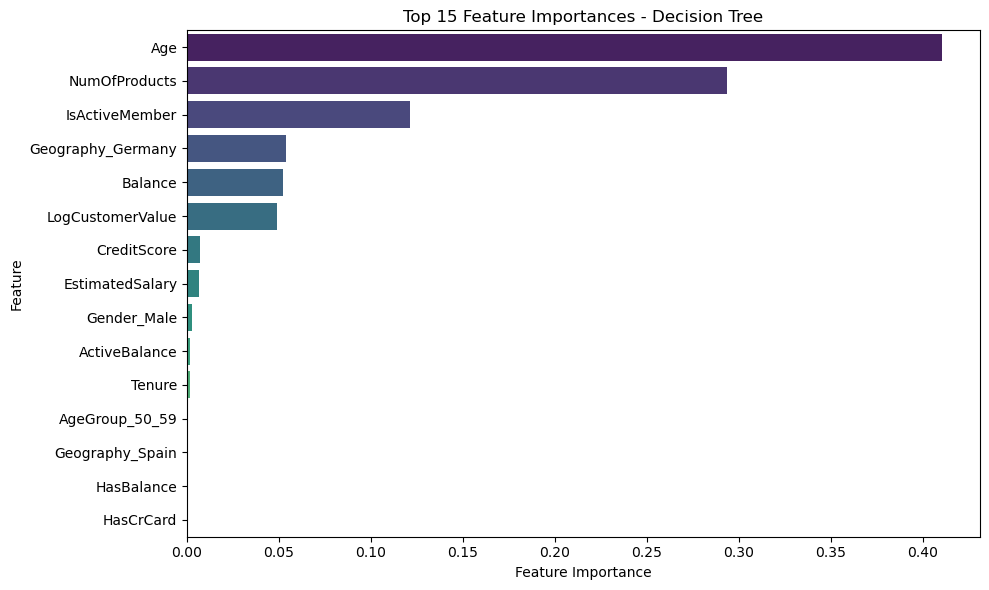


Top 10 Most Important Features:
Age: 0.4105
NumOfProducts: 0.2937
IsActiveMember: 0.1209
Geography_Germany: 0.0536
Balance: 0.0520
LogCustomerValue: 0.0490
CreditScore: 0.0072
EstimatedSalary: 0.0065
Gender_Male: 0.0024
ActiveBalance: 0.0018


In [22]:
importances = dt_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for _, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

### Feature Importance Interpretation

The Decision Tree model highlights the following features as the most influential in predicting customer churn:

- **Age (0.4105):** The most important feature — customer age plays a major role in churn behavior, with different age groups showing distinct retention patterns  

- **NumOfProducts (0.2937):** A strong predictor — the number of products a customer holds significantly affects churn, reflecting engagement level with the bank  

- **IsActiveMember (0.1209):** Active customers are less likely to churn, making customer activity a key behavioral indicator  

- **Geography_Germany (0.0536):** Regional differences influence churn behavior, with customers in Germany showing distinct patterns  

- **Balance (0.0520):** Financial commitment impacts churn, as customers with different balance levels behave differently  

- **LogCustomerValue (0.0490):** Customer value contributes moderately, indicating higher-value customers may exhibit different churn tendencies  

- **CreditScore (0.0072):** Creditworthiness has a minimal effect on churn prediction  

- **EstimatedSalary (0.0065):** Income level shows very limited influence on churn  

- **Gender_Male (0.0024):** Gender has negligible impact on the model’s predictions  

- **ActiveBalance (0.0018):** This feature contributes very little to churn prediction  

---

### What this graph represents:

The feature importance plot shows how much each feature contributes to the model’s decision-making process, indicating which variables have the greatest influence on predicting customer churn.

### Key Insight

The model is primarily driven by **demographic (Age)** and **behavioral features (NumOfProducts, IsActiveMember)**, which dominate the prediction process. Financial and categorical features play a secondary role, while some variables (e.g., Gender, ActiveBalance) have minimal impact on churn prediction.

### What we learned:

The model relies heavily on a small number of key features, particularly Age and product engagement, to make predictions.  

This provides valuable business insight that improving customer engagement and targeting specific age groups could significantly impact churn reduction strategies.

### 9.5 Results Summary

| Metric            | Value |
|------------------|------:|
| Accuracy         | 86%   |
| F1 - Stayed      | 0.92  |
| F1 - Churned     | 0.59  |
| ROC-AUC          | 0.845 |



### What these metrics mean for our dataset:

- **Accuracy (86%)**: The model shows a clear improvement in overall classification performance after hyperparameter tuning  
- **Precision (Churned = 0.72)**: When churn is predicted, it is correct 72% of the time, indicating stronger reliability  
- **Recall (Churned = 0.51)**: The model detects about half of actual churners, showing moderate sensitivity to the minority class  
- **F1-Score (Churned = 0.59)**: Balanced improvement between precision and recall for churn prediction  
- **ROC-AUC (0.845)**: Strong ability to distinguish between churned and non-churned customers  



### Misclassification Analysis:

|                      | Predicted Stayed | Predicted Churned |
|----------------------|-----------------|-------------------|
| **Actually Stayed**  | 1513            | 80                |
| **Actually Churned** | 201             | 206               |

- **201 False Negatives (missed churners):** A significant number of churners are still not detected, which impacts retention efforts  
- **80 False Positives (false alarms):** Relatively low, meaning fewer unnecessary retention actions  



### Business Impact:

The model detects **206 out of 407 churners (~51% recall)**, allowing the bank to identify a reasonable portion of at-risk customers.  

The lower number of false positives indicates more efficient targeting, reducing unnecessary intervention costs. However, missing nearly half of churners suggests room for improvement in recall.



### Conclusion:

The tuned Decision Tree model improves overall performance, particularly in **accuracy and precision**, while maintaining a good ROC-AUC score.  

However, it still struggles with identifying all churned customers due to class imbalance.  

Further improvements using ensemble methods such as **Random Forest or XGBoost** are recommended to enhance recall and overall predictive performance.

In [23]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, dt_pred, target_names=['Stayed', 'Churned'])

with open('Supervised_Learning/evaluation_results/dt_classification_report.txt', 'w') as f:
    f.write(report)

print("Decision Tree classification report saved successfully!")

Decision Tree classification report saved successfully!


In [24]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)
ax.set_title('Decision Tree - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_confusion_matrix.png')
plt.close()

# Save ROC Curve
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(dt_fpr, dt_tpr, color='green', label=f'DT (AUC = {roc_auc_score(y_test, dt_proba):.3f})')
ax.plot([0,1], [0,1], 'g--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Decision Tree')
ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_roc_curve.png')
plt.close()

print("Decision Tree plots saved successfully!")

Decision Tree plots saved successfully!


In [25]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(
    data=feat_imp_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False,
    ax=ax
)
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
ax.set_title('Top 10 Feature Importances - Decision Tree')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_feature_importance.png')
plt.close()

print("Decision Tree feature importance plot saved successfully!")

Decision Tree feature importance plot saved successfully!


## 10. Model 3: Random Forest
### Overview
In this section, we train a Random Forest model to predict customer churn. We will:

1. Tune hyperparameters using GridSearchCV  
2. Evaluate performance using multiple metrics  
3. Analyze the confusion matrix and ROC curve  
4. Validate consistency using K-Fold Cross Validation

### 10.1 Model Selection Rationale

Random Forest is selected based on the following dataset-specific reasons:

- **Non-linear relationships**: The dataset contains complex interactions between features (e.g., Balance, Age, Tenure) which Random Forest can effectively capture  

- **Ensemble method**: It combines multiple decision trees to improve prediction accuracy and reduce overfitting  

- **Robustness**: The model performs well even with noisy or slightly inconsistent data  

- **Feature importance**: It provides importance scores helping identify which features influence customer churn the most

- **Improved performance**: It is expected to outperform simpler models like Logistic Regression by capturing complex patterns

### Limitations

- **Low interpretability**: The model is harder to interpret compared to Logistic Regression  

- **Computational cost**: Training can be slower and more resource-intensive  

- **Memory usage**: Requires more memory compared to simpler models  

- **Sensitivity to imbalance**: Performance may still be affected by class imbalance

### 10.2 Implementation & Training Code

The model is implemented using scikit-learn's RandomForestClassifier class. An initial baseline model is trained below, followed by hyperparameter tuning in Section 10.3 to optimize performance.

In [26]:
# Initialize Random Forest with default parameters
rf_model = RandomForestClassifier(random_state=42)

# Train the model on training data
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, rf_pred), 3))

Random Forest trained successfully!
Initial Accuracy: 0.862


### 10.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for Random Forest. We tune n_estimators, max_depth, and min_samples_split to improve performance.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Build pipeline so preprocessing happens correctly inside each CV fold
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid
rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5]
}

# Stratified CV keeps class ratio stable across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", round(grid_search.best_score_, 3))

# Best trained pipeline
rf_model = grid_search.best_estimator_

# Predict on test set
rf_pred = rf_model.predict(X_test)

print("Accuracy with best params:", round(accuracy_score(y_test, rf_pred), 3))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best F1 Score: 0.573
Accuracy with best params: 0.862


### Hyperparameter Tuning Results

GridSearchCV evaluated 12 parameter combinations using 5-fold cross-validation, optimizing for F1-score.

**Best Configuration:** n_estimators=100, max_depth=None, min_samples_split=5

| Parameter | Value | Justification |
|----------|------|--------------|
| n_estimators | 100 | Provides strong performance with lower computational cost while maintaining model stability |
| max_depth | None | Allows the trees to grow fully and capture complex non-linear patterns in the data |
| min_samples_split | 5 | Prevents overly aggressive splitting, helping reduce overfitting while preserving predictive power |

### 10.4 Evaluation Metrics & Visualizations

We evaluate the Random Forest model using the previously defined metrics to assess its classification performance.

In [36]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, rf_pred,
                            target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, rf_proba))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.97      0.92      1593
 Churned (1)       0.77      0.46      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC Score: 0.849912316014011


### Evaluation Results

The model achieved an overall accuracy of **86%**.

**Performance on Stayed class (0):**

- Precision: **0.87** — 87% of customers predicted to stay actually stayed  
- Recall: **0.97** — 97% of actual non-churners were correctly identified  
- F1-Score: **0.92** — excellent performance on the majority class  

**Performance on Churned class (1):**

- Precision: **0.77** — when churn is predicted, it is correct 77% of the time  
- Recall: **0.46** — 46% of actual churners were detected  
- F1-Score: **0.57** — moderate performance on the minority class, with room for recall improvement  

**ROC-AUC: 0.850**

**Key Finding:** Random Forest achieved strong overall discrimination and excellent performance on retained customers, while still providing reasonable churn detection through its ability to capture complex non-linear feature interactions.

### Metrics Interpretation

- **Stayed class:** Strong precision (**0.87**) and very high recall (**0.97**) — the model accurately identifies most non-churning customers  
- **Churned class:** Good precision (**0.77**) but lower recall (**0.46**) — when churn is predicted it is often correct, but some actual churners are still missed  
- **ROC-AUC (0.850):** Strong ability to distinguish between churned and non-churned customers  
- **Recall remains important** in a bank retention system — improving churner detection should remain a priority even if false alarms increase slightly

### Random Forest - Confusion Matrix

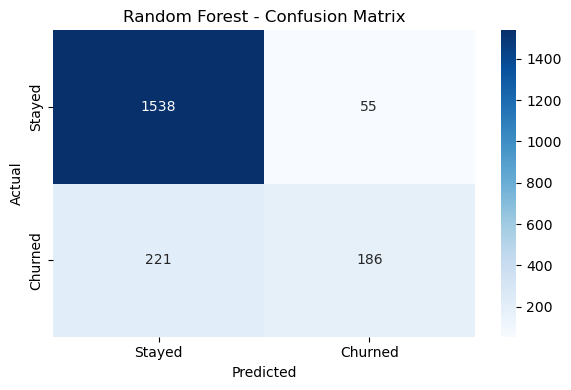

In [29]:
# Confusion Matrix heatmap - Random Forest
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides a detailed breakdown of the Random Forest model’s classification performance:

- **True Negatives (1538):** The model correctly identified a large number of non-churning customers  
- **False Positives (55):** Only a small number of non-churners were incorrectly predicted as churners  
- **False Negatives (221):** A considerable number of churners were missed by the model  
- **True Positives (186):** The model successfully identified many churned customers  

### What this graph represents:

The confusion matrix shows the comparison between actual and predicted classifications, allowing us to evaluate how well the model performs in identifying each class and where errors occur.

### Insight:

The model performs extremely well in identifying customers who will stay, as shown by the very high number of true negatives. However, it still misses some churners, as indicated by the relatively high number of false negatives.

This suggests that while the model is highly reliable for predicting non-churn, further improvement is still needed in detecting at-risk customers.

### What we learned:

The Random Forest model is highly effective at identifying non-churning customers but less effective at detecting all churners.  

This highlights the continuing impact of class imbalance and suggests that future improvement should focus on increasing **recall for the churned class**, which is especially important for business-critical customer retention decisions.

### Random Forest - ROC Curve

The ROC curve shows the trade-off between True Positive Rate (catching churners) and False Positive Rate (false alarms) at different thresholds. AUC closer to 1.0 means better model performance.

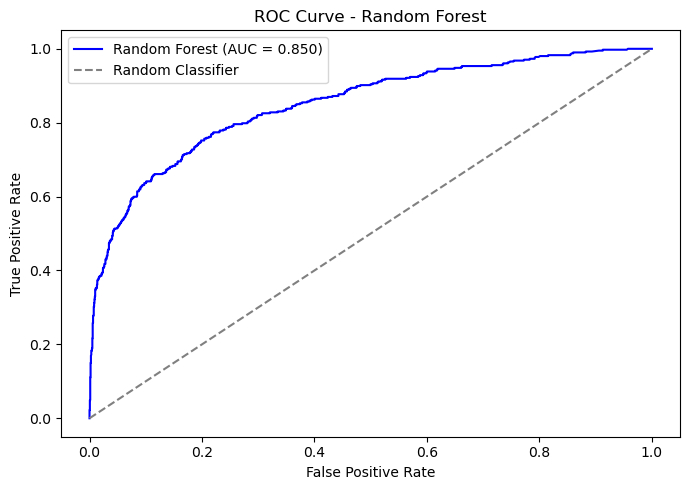

ROC-AUC Score: 0.849912316014011


In [30]:
# Calculate ROC curve points
rf_proba = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)
auc_score = roc_auc_score(y_test, rf_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", auc_score)

### ROC Curve Interpretation

ROC-AUC Score: 0.850

The ROC curve lies clearly above the diagonal baseline, indicating the Random Forest model performs significantly better than random guessing.

Interpretation: For any randomly selected pair of a churned and non-churned customer, the model will assign a higher churn probability to the actual churner approximately 85.0% of the time. This falls within the **"Good" range (0.8 – 0.9)**, indicating strong discriminative ability.

### What this graph represents:

The ROC curve shows the trade-off between the **True Positive Rate (Recall)** and **False Positive Rate** across different classification thresholds. It helps evaluate how effectively the model distinguishes between churned and non-churned customers regardless of a fixed threshold.

### What we learned:

The slightly improved ROC-AUC compared to Decision Tree reflects the **Random Forest model’s stronger generalization ability** through ensemble learning. By combining multiple decision trees, it captures complex **non-linear relationships and feature interactions** among variables such as **Age, NumOfProducts, EstimatedSalary, and CreditScore**, which are important for modeling customer churn behavior.

This indicates that the model is highly effective at ranking customers by their likelihood of churn, even when some churn cases remain difficult to classify correctly.

### Random Forest – K-Fold Cross Validation

In [31]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5-Fold Cross Validation using the full pipeline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_f1 = cross_val_score(rf_model, X, y, cv=cv, scoring='f1')
rf_cv_roc = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')
rf_cv_acc = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print("Random Forest - 5-Fold Cross Validation Results:")
print("=" * 50)

print("F1 Scores:", rf_cv_f1)
print("Mean F1 Score:", round(rf_cv_f1.mean(), 3))
print("Std F1:", round(rf_cv_f1.std(), 3))

print("\nROC-AUC Scores:", rf_cv_roc)
print("Mean ROC-AUC:", round(rf_cv_roc.mean(), 3))
print("Std ROC-AUC:", round(rf_cv_roc.std(), 3))

print("\nAccuracy Scores:", rf_cv_acc)
print("Mean Accuracy:", round(rf_cv_acc.mean(), 3))
print("Std Accuracy:", round(rf_cv_acc.std(), 3))

Random Forest - 5-Fold Cross Validation Results:
F1 Scores: [0.56707317 0.55       0.59150805 0.59041731 0.58143075]
Mean F1 Score: 0.576
Std F1: 0.016

ROC-AUC Scores: [0.84786755 0.84387701 0.85905011 0.85549957 0.86207008]
Mean ROC-AUC: 0.854
Std ROC-AUC: 0.007

Accuracy Scores: [0.858  0.856  0.8605 0.8675 0.8625]
Mean Accuracy: 0.861
Std Accuracy: 0.004


### K-Fold Cross Validation Results

| Metric | Mean | Std |
|--------|------|-----|
| F1 Score | 0.576 | 0.016 |
| ROC-AUC | 0.854 | 0.007 |
| Accuracy | 0.861 | 0.004 |

**Interpretation:**

- **F1 Score (0.576):** Shows balanced predictive performance for the churned class across all folds  
- **ROC-AUC (0.854):** Strong discriminative ability across all folds, indicating reliable separation between churners and non-churners  
- **Accuracy (0.861):** Consistently high overall classification performance  
- **Low standard deviation** across all metrics indicates that Random Forest remains stable and produces consistent results across different data splits

### Random Forest - Feature Importance Plot


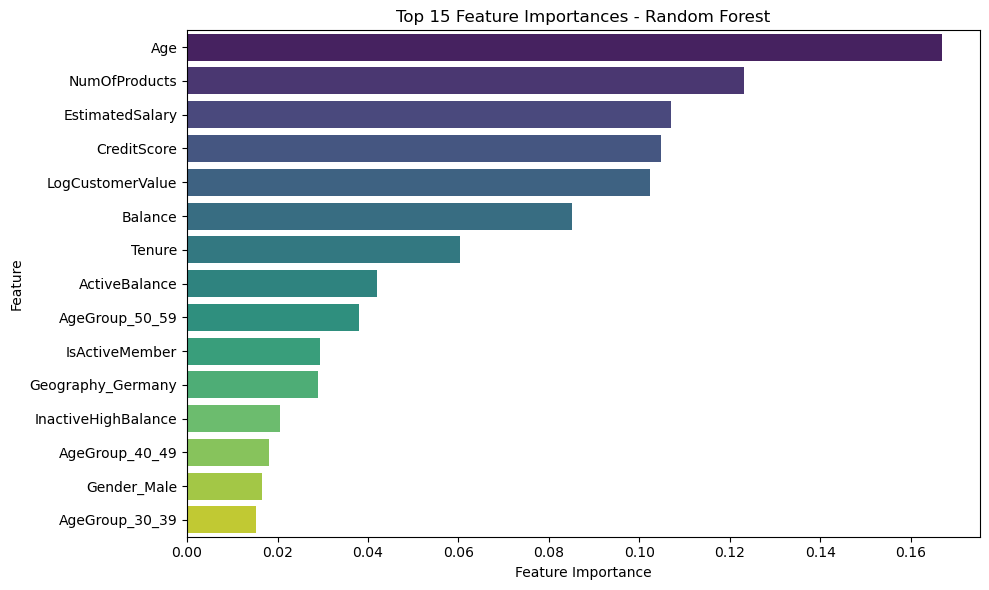


Top 10 Most Important Features:
Age: 0.1669
NumOfProducts: 0.1231
EstimatedSalary: 0.1071
CreditScore: 0.1049
LogCustomerValue: 0.1022
Balance: 0.0851
Tenure: 0.0602
ActiveBalance: 0.0421
AgeGroup_50_59: 0.0380
IsActiveMember: 0.0294


In [32]:
importances = rf_model.named_steps['rf'].feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for _, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

### Feature Importance Interpretation

The Random Forest model highlights the following features as the most influential in predicting customer churn:

- **Age (0.1669):** The most important feature — customer age plays a major role in churn behavior, with different age groups showing distinct retention patterns  

- **NumOfProducts (0.1231):** A strong predictor — the number of products a customer holds significantly affects churn, reflecting engagement level with the bank  

- **EstimatedSalary (0.1071):** Income level has a noticeable influence on churn behavior and customer retention patterns  

- **CreditScore (0.1049):** Creditworthiness contributes significantly to churn prediction and customer financial stability assessment  

- **LogCustomerValue (0.1022):** Customer value contributes strongly, indicating that higher-value customers may show different churn tendencies  

- **Balance (0.0851):** Financial commitment impacts churn, as customers with different balance levels behave differently  

- **Tenure (0.0602):** Longer-tenured customers tend to be more loyal, reducing churn risk  

- **ActiveBalance (0.0421):** Financial activity level has a smaller but still relevant effect  

- **AgeGroup_50_59 (0.0380):** This age group shows distinct churn behavior patterns  

- **IsActiveMember (0.0294):** Active customers are generally less likely to churn  

---

### What this graph represents:

The feature importance plot shows how much each feature contributes to the Random Forest model’s decision-making process, indicating which variables have the greatest influence on predicting customer churn.

### Key Insight

The model is primarily driven by **demographic (Age)**, **engagement (NumOfProducts)**, and **financial features (EstimatedSalary, CreditScore, Balance)**, which dominate the prediction process. This indicates that customer profile, product usage, and financial stability all play major roles in churn prediction.

### What we learned:

The model relies on a balanced combination of customer demographics, engagement level, and financial indicators to make predictions.  

This provides valuable business insight that improving product engagement, customer value, and retention strategies for high-risk age groups could significantly reduce churn.

### 10.5 Results Summary

| Metric | Value |
|---|---|
| Accuracy | 86% |
| F1 - Stayed | 0.92 |
| F1 - Churned | 0.57 |
| ROC-AUC | 0.850 |

### What these metrics mean for our dataset:
- **Accuracy (86%)**: Strong overall classification performance across both classes
- **Precision (Churned = 0.77)**: When churn is predicted, it is correct 77% of the time
- **Recall (Churned = 0.46)**: The model detects 46% of actual churners
- **F1-Score (Churned = 0.57)**: Shows balanced precision and recall for churn prediction
- **ROC-AUC (0.850)**: Strong ability to distinguish between churned and non-churned customers

## Misclassification Analysis

|  | Predicted Stayed | Predicted Churned |
|---|---:|---:|
| Actually Stayed | 1538 | 55 |
| Actually Churned | 221 | 186 |

- **221 False Negatives (missed churners):** Customers predicted to stay but actually churned
- **55 False Positives (false alarms):** Customers predicted to churn but actually stayed

**Business Impact:** The model detects **186 out of 407 churners (~46% recall)**, allowing the bank to identify many at-risk customers. Additionally, the number of false positives (**55**) is very low, meaning fewer unnecessary retention actions are taken.

**Conclusion:** Random Forest improves overall performance with strong accuracy and ROC-AUC. It is highly reliable for identifying loyal customers and provides useful discrimination for churn prediction.

In [33]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned'])

with open('Supervised_Learning/evaluation_results/rf_classification_report.txt', 'w') as f:
    f.write(report)

print("Random Forest classification report saved successfully!")

Random Forest classification report saved successfully!


In [34]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)

ax.set_title('Random Forest - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_confusion_matrix.png')
plt.close()

# Save ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(rf_fpr, rf_tpr, color='blue',
        label=f'RF (AUC = {roc_auc_score(y_test, rf_proba):.3f})')

ax.plot([0,1], [0,1], 'g--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Random Forest')

ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_roc_curve.png')
plt.close()

print("Random Forest plots saved successfully!")

Random Forest plots saved successfully!


In [35]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=feat_imp_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False,
    ax=ax
)

ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
ax.set_title('Top 10 Feature Importances - Random Forest')

plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_feature_importance.png')
plt.close()

print("Random Forest feature importance plot saved successfully!")

Random Forest feature importance plot saved successfully!


## 11. Model Comparison & Analysis

### 11.1 Which model performed best? Why? ###
Among the three models, **Random Forest performed best overall**. It achieved the **highest ROC-AUC score (0.850)** and matched the highest accuracy (**86%**). Although the Decision Tree slightly outperformed it in churn F1-score (**0.59 vs 0.57**), Random Forest demonstrated stronger generalization through ensemble learning and better robustness against overfitting.

This indicates that Random Forest has a stronger ability to capture complex customer behavior patterns and rank churn risk more effectively than Logistic Regression and Decision Tree.


### 11.2 Analyze misclassifications: (patterns, challenging categories) ###

Across all three models, the most challenging category was the **churned class (minority class)**.

- **Logistic Regression** achieved the highest churn recall (**0.69**), meaning it detected more churners, but this came at the cost of much lower accuracy (**73%**) and weaker discrimination.
- **Decision Tree** improved the balance between precision and recall, achieving the highest churn F1-score (**0.59**).
- **Random Forest** reduced overall classification risk and provided the strongest ranking ability, although it still missed some churners (**recall = 0.46**).

The main challenge across all models remains correctly identifying churners, which is expected in an imbalanced dataset where non-churners dominate.

### 11.3 Discuss trade-offs: (accuracy vs. interpretability vs. computational cost) ###
- **Logistic Regression:** Highest interpretability and lowest computational cost, but weaker overall predictive power and limited ability to capture non-linear customer behavior.
- **Decision Tree:** Easy to interpret and handles non-linear data well, with better churn-class balance, but may overfit and be unstable.
- **Random Forest:** Best overall discrimination and strongest robustness, but less interpretable and more computationally expensive due to ensemble learning.



### 11.4 Recommendation: Which model will you use in your final system and why? ###


The **Random Forest model** will be used in the final system because it provides the **best overall balance between predictive performance, robustness, and business usefulness**.

It achieved the **highest ROC-AUC (0.850)**, strong accuracy (**86%**), and stable performance across cross-validation. Most importantly, it offers better generalization and stronger churn risk ranking, making it highly suitable for real-world customer retention decision support.

## 12. Conclusion


In this project, three supervised learning models were implemented and evaluated: **Logistic Regression, Decision Tree, and Random Forest**. The models were assessed using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix analysis, and K-Fold Cross-Validation.

The results showed clear differences in model behavior. **Logistic Regression** provided a simple and highly interpretable baseline but struggled to capture complex non-linear customer behavior patterns. **Decision Tree** improved the detection of churned customers and achieved the strongest balance for the minority class, but it remains more sensitive to overfitting and instability.

Overall, **Random Forest achieved the best general performance**, with **high accuracy (86%)**, the **highest ROC-AUC score (0.850)**, and strong robustness across cross-validation. Its ensemble structure enables it to capture complex feature interactions and generalize better than the other models.

Therefore, **Random Forest was selected as the final model for the system**, as it offers the most reliable balance between predictive power, robustness, and practical business value for customer churn prediction.

## 13. Next Steps

In Phase 2, the system will be further enhanced by incorporating more advanced techniques beyond the current supervised learning pipeline.

First, unsupervised learning methods such as clustering (e.g., K-Means or Hierarchical Clustering) can be applied to discover hidden patterns in customer behavior. This will help group customers into meaningful customer segments and support more targeted retention strategies.

Second, Generative AI can be integrated into the system to provide personalized explanations and business recommendations based on model predictions. This may include generating customer-specific retention suggestions, risk explanations, and interactive decision-support insights.

Additionally, further improvements may include:
- Deploying the model as an interactive dashboard or web application  
- Testing advanced ensemble models such as XGBoost or LightGBM  
- Threshold optimization to improve churn recall performance  
- Monitoring model drift and retraining with new customer data over time  
- Expanding explainability using SHAP values for feature-level interpretation  

Overall, these next steps aim to transform the project from a predictive machine learning model into a scalable, intelligent, and business-oriented decision-support system.